# OLS Fantasy Points Predictor — Methodology & Models

Predicts a player's UEFA Champions League Fantasy points from their **domestic-league** performance, using four separate position-specific OLS regressions (GK / DEF / MID / FWD), trained on 5 completed UCL seasons.

## Scope decisions (as agreed)
- **Target variable is reconstructed, not official** — UEFA does not publish historical fantasy points anywhere. Each player-season's UCL fantasy points are reconstructed by applying the known position-weighted scoring formula to that season's actual UCL match stats (goals, assists, tackles, clean sheets, saves). This means the target itself omits bonuses the formula can't see from bulk stats: Player of the Match, penalties won/missed/conceded, cards, own goals. Accepted as a known limitation rather than a blocker.
- **5 seasons of history**: 2021/22 through 2025/26 — capped at 5 to avoid the pre-2024/25 competition format change (old group-stage-then-knockout vs. the current 36-team league phase) becoming too dominant a share of the training data, and because advanced-stat tracking (tackles, xG) gets sparse further back.
- **16 domestic leagues** covering every league that feeds a 2026/27 UCL club: Premier League, Bundesliga, LaLiga, Ligue 1, Serie A, Eredivisie, Süper Lig, Austrian Bundesliga, Eliteserien, Liga Portugal, Ukrainian Premier League, Niké Liga (Slovakia), Azerbaijan Premier League, Czech First League, Greek Super League, Belgian Pro League.
- **No age, no domestic cups, no current-season (2026/27) data** in the training set — excluded by explicit choice to keep scope tight; current-season data is too small a sample this early, cups needed separate tournament-ID lookups not yet done, and age needs a per-player birthdate lookup not yet joined into this panel.
- **Position tagging uses each player's *current* UEFA Fantasy position** — a real limitation for older seasons, since a player active 4-5 years ago may have since retired or dropped out of the current fantasy pool entirely, silently excluding them from the panel (this is why GK n=110 and FWD n=170 are the two smallest samples — retired/moved-on goalkeepers and forwards are more likely to have aged out of the current pool than a still-effective 27-year-old midfielder).
- **`league_strength`** = that country's UEFA association coefficient points for that specific season (see `uefa_country_rankings.csv`) — a continuous team/league-quality control standing in for match-by-match fixture difficulty, which we deliberately did not model (UCL league-phase draws are broad and roughly even, and clubs prioritize starting strong XIs in it).

## Data files used
- `regression_training_panel.csv` — the panel this notebook fits on (1,323 player-seasons)
- `uefa_country_rankings.csv` — league-strength lookup (for reference; already joined into the panel's `league_strength` column)
- `predicted_fantasy_points_2627.csv` — this model's output, applied to the full current player pool's 2025/26 domestic form

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

panel = pd.read_csv('regression_training_panel.csv')
panel.head()

,sofa_id,name,pos,season,league,country,dom_g,dom_a,dom_tk,dom_cs,dom_sv,dom_rt,league_strength,target_ucl_fantasy_pts
0,769333,Christopher Nkunku,FWD,2122,Bund,Germany,20,13,23,2,0,7.59,17.125,34
1,259117,Joshua Kimmich,MID,2122,Bund,Germany,3,11,39,6,0,7.79,17.125,9
2,293519,Leroy Sané,MID,2122,Bund,Germany,7,7,28,1,0,7.04,17.125,54
3,256219,Paulo Dybala,FWD,2122,SerieA,Italy,10,5,30,2,0,7.41,22.357,16
4,845291,Josep Martínez,GK,2122,Bund,Germany,0,0,0,0,1,5.90,17.125,5


## 1. Panel overview

In [2]:
print('Total player-seasons:', len(panel))
print('\nBy position:')
print(panel['pos'].value_counts())
print('\nBy season:')
print(panel['season'].value_counts().sort_index())

Total player-seasons: 1323

By position:
pos
MID    567
DEF    476
FWD    170
GK     110
Name: count, dtype: int64

By season:
season
2122    175
2223    193
2324    236
2425    330
2526    389
Name: count, dtype: int64


## 2. Fit one OLS model per position

Using heteroskedasticity-robust standard errors (HC1) throughout — residuals are known to be non-normal and heavy-tailed (a handful of elite players score far more fantasy points than the bulk of squad players), confirmed below by the Jarque-Bera test in each summary.

**GK** drops `dom_g` (goals) and `dom_a` (assists) — both are near-zero-variance for goalkeepers (94%+ of keeper-seasons have zero assists, effectively all have zero goals), which makes their estimated coefficients unstable and spuriously significant off a handful of outlier rows rather than a real relationship. Confirmed by checking the distribution before dropping them (see `squad_advanced_stats.ipynb`-style diagnostic below).

In [3]:
# Diagnostic: why dom_g / dom_a are dropped for GK
gk = panel[panel['pos'] == 'GK']
print('GK dom_g value counts:')
print(gk['dom_g'].value_counts())
print('\nGK dom_a value counts:')
print(gk['dom_a'].value_counts())
print(f"\n{(gk['dom_a'] == 0).mean():.1%} of GK player-seasons have zero domestic assists")

GK dom_g value counts:
dom_g
0    110
Name: count, dtype: int64

GK dom_a value counts:
dom_a
0    103
1      5
2      1
4      1
Name: count, dtype: int64

93.6% of GK player-seasons have zero domestic assists


In [4]:
FEATURES = {
    'GK':  ['dom_sv', 'dom_cs', 'dom_rt', 'league_strength'],
    'DEF': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
    'MID': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
    'FWD': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
}

models = {}
for pos, feats in FEATURES.items():
    sub = panel[panel['pos'] == pos]
    X = sm.add_constant(sub[feats])
    y = sub['target_ucl_fantasy_pts']
    model = sm.OLS(y, X).fit(cov_type='HC1')
    models[pos] = model
    print(f'=== {pos} (n={len(sub)}) — R\u00b2={model.rsquared:.3f}, Adj. R\u00b2={model.rsquared_adj:.3f} ===')
    print(model.summary())
    print('\n')

=== GK (n=110) — R²=0.398, Adj. R²=0.375 ===
                              OLS Regression Results                              
Dep. Variable:     target_ucl_fantasy_pts   R-squared:                       0.398
Model:                                OLS   Adj. R-squared:                  0.375
Method:                     Least Squares   F-statistic:                     19.60
Date:                    Thu, 10 Sep 2026   Prob (F-statistic):           4.51e-12
Time:                            21:56:18   Log-Likelihood:                -394.65
No. Observations:                     110   AIC:                             799.3
Df Residuals:                         105   BIC:                             812.8
Df Model:                               4                                         
Covariance Type:                      HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

=== FWD (n=170) — R²=0.449, Adj. R²=0.428 ===
                              OLS Regression Results                              
Dep. Variable:     target_ucl_fantasy_pts   R-squared:                       0.449
Model:                                OLS   Adj. R-squared:                  0.428
Method:                     Least Squares   F-statistic:                     23.60
Date:                    Thu, 10 Sep 2026   Prob (F-statistic):           5.66e-20
Time:                            21:56:18   Log-Likelihood:                -638.63
No. Observations:                     170   AIC:                             1291.
Df Residuals:                         163   BIC:                             1313.
Df Model:                               6                                         
Covariance Type:                      HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

## 3. Coefficient grid — all four models side by side

In [5]:
VAR_LABELS = {
    'const': 'Intercept',
    'dom_g': 'Domestic goals',
    'dom_a': 'Domestic assists',
    'dom_tk': 'Domestic tackles',
    'dom_cs': 'Domestic clean sheets',
    'dom_sv': 'Domestic saves',
    'dom_rt': 'Domestic avg. rating',
    'league_strength': "League's UEFA coefficient (that season)",
}

rows = []
for pos, model in models.items():
    for var in model.params.index:
        rows.append({
            'Position': pos,
            'Variable': var,
            'Description': VAR_LABELS.get(var, var),
            'Beta': round(model.params[var], 4),
            'StdErr_HC1': round(model.bse[var], 4),
            'z': round(model.tvalues[var], 3),
            'p': round(model.pvalues[var], 4),
            'CI_low': round(model.conf_int().loc[var, 0], 3),
            'CI_high': round(model.conf_int().loc[var, 1], 3),
        })
coef_grid = pd.DataFrame(rows)
coef_grid

,Position,Variable,Description,Beta,StdErr_HC1,z,p,CI_low,CI_high
0,GK,const,Intercept,21.8517,18.1030,1.207,0.2274,-13.629,57.333
1,GK,dom_sv,Domestic saves,0.1029,0.0434,2.373,0.0177,0.018,0.188
2,GK,dom_cs,Domestic clean sheets,0.8841,0.2651,3.335,0.0009,0.365,1.404
3,GK,dom_rt,Domestic avg. rating,-3.6837,2.6519,-1.389,0.1648,-8.881,1.514
4,GK,league_strength,League's UEFA coefficient (that season),0.2768,0.1496,1.850,0.0643,-0.016,0.570
5,DEF,const,Intercept,-13.6419,10.3929,-1.313,0.1893,-34.012,6.728
6,DEF,dom_g,Domestic goals,1.0350,0.4591,2.255,0.0242,0.135,1.935
7,DEF,dom_a,Domestic assists,0.7296,0.2515,2.901,0.0037,0.237,1.223
8,DEF,dom_tk,Domestic tackles,0.0789,0.0279,2.828,0.0047,0.024,0.134
9,DEF,dom_cs,Domestic clean sheets,0.4021,0.1360,2.956,0.0031,0.136,0.669


In [6]:
coef_grid.to_csv('regression_model_coefficients.csv', index=False)
print('Saved regression_model_coefficients.csv')

Saved regression_model_coefficients.csv


## 4. Model fit summary

In [7]:
fit_summary = pd.DataFrame({
    'Position': list(models.keys()),
    'N': [int(m.nobs) for m in models.values()],
    'R2': [round(m.rsquared, 3) for m in models.values()],
    'Adj_R2': [round(m.rsquared_adj, 3) for m in models.values()],
})
fit_summary

,Position,N,R2,Adj_R2
0,GK,110,0.398,0.375
1,DEF,476,0.228,0.218
2,MID,567,0.347,0.340
3,FWD,170,0.449,0.428


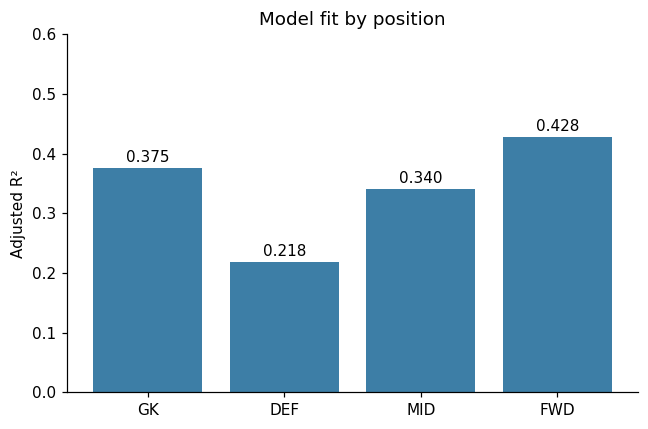

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(fit_summary['Position'], fit_summary['Adj_R2'], color='#3d7ea6')
ax.set_ylabel('Adjusted R\u00b2')
ax.set_title('Model fit by position')
ax.set_ylim(0, 0.6)
for i, v in enumerate(fit_summary['Adj_R2']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

## 5. Applying the models — predicted 2026/27 UCL fantasy points

Predictions were generated by feeding each current player's actual **2025/26 domestic-season stats** (their most recent completed season) plus that league's 2025/26 UEFA coefficient into the fitted model for their position, across the full current UEFA Fantasy player pool (937 of 1,163 players had enough domestic data to score; the rest lack a clean position match or domestic minutes and are excluded).

Full results already saved to `predicted_fantasy_points_2627.csv` — loaded here for reference.

In [9]:
preds = pd.read_csv('predicted_fantasy_points_2627.csv')
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    print(f'--- Top 10 {pos} ---')
    display(preds[preds['Position'] == pos].sort_values('PredictedUCLFantasyPts', ascending=False).head(10))

--- Top 10 GK ---


,Name,Position,Team,League,PredictedUCLFantasyPts
452,Mile Svilar,GK,AS Roma,SerieA,27.95
453,David Raya,GK,Arsenal,PL,27.34
454,Jean Butez,GK,Como,SerieA,26.48
455,Gianluigi Donnarumma,GK,Manchester City,PL,25.22
456,Diogo Costa,GK,FC Porto,Portugal,24.49
457,Gregor Kobel,GK,Borussia Dortmund,Bund,24.00
458,Robert Sánchez,GK,Chelsea,PL,22.38
459,Thomas Strakosha,GK,AEK Athens,Greece,22.22
460,Joan García,GK,FC Barcelona,LaLiga,21.80
461,Yann Sommer,GK,Inter,SerieA,21.57


--- Top 10 DEF ---


,Name,Position,Team,League,PredictedUCLFantasyPts
0,Federico Dimarco,DEF,Inter,SerieA,32.92
1,Alejandro Grimaldo,DEF,Bayer 04 Leverkusen,Bund,25.57
2,Carlos Romero,DEF,Espanyol,LaLiga,24.86
3,Nico O'Reilly,DEF,Manchester City,PL,23.73
4,Jurriën Timber,DEF,Arsenal,PL,23.43
5,Marc Guéhi,DEF,Manchester City,PL,22.26
6,Julian Ryerson,DEF,Borussia Dortmund,Bund,21.62
7,Matheus Nunes,DEF,Manchester City,PL,21.12
8,Maximilian Mittelstädt,DEF,VfB Stuttgart,Bund,21.01
9,David Raum,DEF,RB Leipzig,Bund,20.82


--- Top 10 MID ---


,Name,Position,Team,League,PredictedUCLFantasyPts
536,Christos Tzolis,MID,Club Brugge KV,Belgium,35.62
537,Michael Olise,MID,FC Bayern München,Bund,34.80
538,Bruno Fernandes,MID,Manchester United,PL,33.18
539,Lamine Yamal,MID,FC Barcelona,LaLiga,32.16
540,Antoine Semenyo,MID,Manchester City,PL,32.06
541,Luis Díaz,MID,FC Bayern München,Bund,31.14
542,Mika Godts,MID,AFC Ajax,Ered,28.46
543,Vinícius Júnior,MID,Real Madrid,LaLiga,27.96
544,Christoph Baumgartner,MID,RB Leipzig,Bund,27.19
545,Mason Greenwood,MID,Olympique de Marseille,L1,26.63


--- Top 10 FWD ---


,Name,Position,Team,League,PredictedUCLFantasyPts
305,Harry Kane,FWD,FC Bayern München,Bund,39.11
306,Erling Haaland,FWD,Manchester City,PL,36.01
307,Kylian Mbappé,FWD,Real Madrid,LaLiga,28.84
308,Deniz Undav,FWD,VfB Stuttgart,Bund,24.92
309,Vedat Muriqi,FWD,Mallorca,LaLiga,23.43
310,Lautaro Martínez,FWD,Inter,SerieA,22.50
311,Ollie Watkins,FWD,Aston Villa,PL,21.70
312,Ayase Ueda,FWD,Feyenoord,Ered,21.43
313,Nicolò Tresoldi,FWD,Club Brugge KV,Belgium,21.01
314,Georges Mikautadze,FWD,Villarreal,LaLiga,19.33


## 6. Known limitations (be upfront about these when using the output)

- **Reconstructed target, not official fantasy points** — missing Player of the Match, penalty, and card bonuses, both in training and in the applied predictions.
- **No age control** — a 34-year-old and a 22-year-old with identical domestic stat lines get identical predictions. Age (as a quadratic term) was scoped as a planned next step but not yet joined into this panel.
- **No fixture difficulty / rotation risk** — `league_strength` is a season-level, not match-level, adjustment. A player could be predicted well but actually get rotated for a dead-rubber group game.
- **No transfer/new-club adjustment** — a player's prior-season stats may be from an entirely different club, league, or role than the one they're in now (see the Grimaldo example: his 2025/26 domestic stats used here are from Bayer Leverkusen, not his actual 2026/27 club).
- **DEF is the weakest-fitting model (Adj. R\u00b2 \u2248 0.22)** — defensive UCL output is the hardest of the four positions to explain from domestic stats alone, plausibly because clean sheets depend heavily on teammates and opponents, not just the individual defender.
- **Small samples for GK (n=110) and FWD (n=170)** relative to DEF/MID — coefficient estimates for those two positions are less stable; the GK model's sensitivity to which variables are included (see Section 2) is a direct symptom of this.